# Urban Ride Duration Prediction

**Machine Learning Coursework — Homework 1**

neccessary importations

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

observing the dataset

In [ ]:
urban_ride_df = pd.read_csv('data/student_version.csv')

In [108]:
urban_ride_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   record_key           1458644 non-null  object 
 1   carrier_code         1458644 non-null  int64  
 2   start_time           1458644 non-null  object 
 3   end_time             1458644 non-null  object 
 4   rider_total          1458644 non-null  int64  
 5   start_xcoord         1458644 non-null  float64
 6   start_ycoord         1458644 non-null  float64
 7   end_xcoord           1458644 non-null  float64
 8   end_ycoord           1458644 non-null  float64
 9   save_forward_marker  1458644 non-null  object 
 10  elapsed_seconds      1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [109]:
urban_ride_df.head()

,record_key,carrier_code,start_time,end_time,rider_total,start_xcoord,start_ycoord,end_xcoord,end_ycoord,save_forward_marker,elapsed_seconds
0,rid2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,rid2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,rid3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,rid3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,rid2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [110]:
urban_ride_df.describe()

,carrier_code,rider_total,start_xcoord,start_ycoord,end_xcoord,end_ycoord,elapsed_seconds
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


array([[<Axes: title={'center': 'carrier_code'}>,
        <Axes: title={'center': 'rider_total'}>,
        <Axes: title={'center': 'start_xcoord'}>],
       [<Axes: title={'center': 'start_ycoord'}>,
        <Axes: title={'center': 'end_xcoord'}>,
        <Axes: title={'center': 'end_ycoord'}>],
       [<Axes: title={'center': 'elapsed_seconds'}>, <Axes: >, <Axes: >]],
      dtype=object)

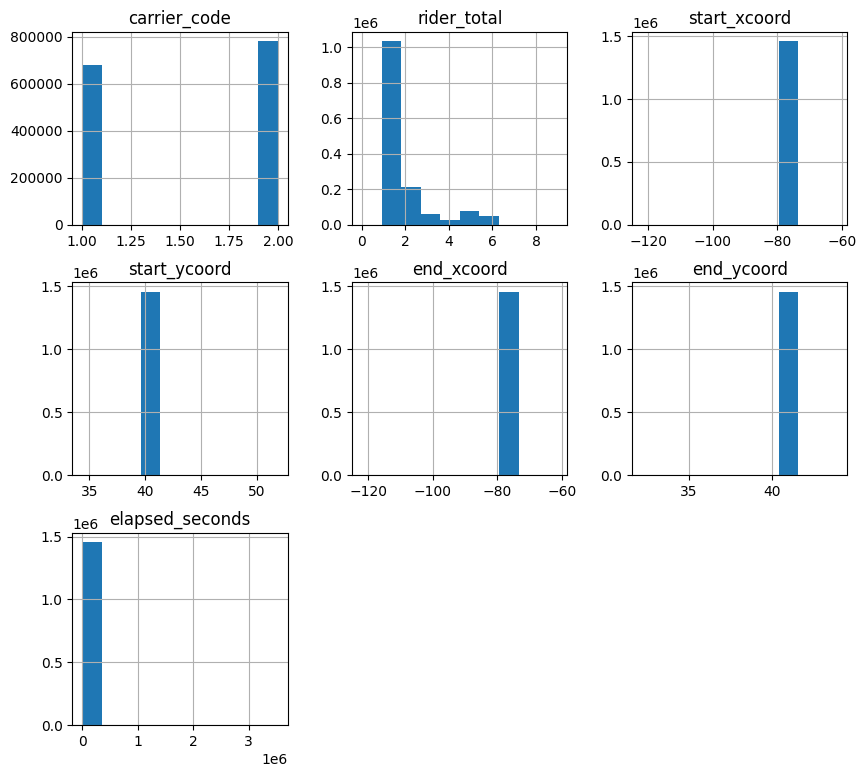

In [111]:
urban_ride_df.hist(bins=10, figsize=(10,9))

In [112]:
urban_ride_df.isnull().sum()

record_key             0
carrier_code           0
start_time             0
end_time               0
rider_total            0
start_xcoord           0
start_ycoord           0
end_xcoord             0
end_ycoord             0
save_forward_marker    0
elapsed_seconds        0
dtype: int64

In [113]:
urban_ride_df.duplicated().sum()

np.int64(0)

In [114]:
urban_ride_df['rider_total'].describe()

count    1.458644e+06
mean     1.664530e+00
std      1.314242e+00
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      9.000000e+00
Name: rider_total, dtype: float64

In [115]:
len(urban_ride_df[~urban_ride_df['rider_total'].between(1, 9)])
urban_ride_df = urban_ride_df[urban_ride_df['rider_total'].between(1, 9)]
urban_ride_df.shape

(1458584, 11)

In [116]:
urban_ride_df.head(10)

,record_key,carrier_code,start_time,end_time,rider_total,start_xcoord,start_ycoord,end_xcoord,end_ycoord,save_forward_marker,elapsed_seconds
0,rid2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,rid2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,rid3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,rid3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,rid2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
5,rid0801584,2,2016-01-30 22:01:40,2016-01-30 22:09:03,6,-73.982857,40.742195,-73.992081,40.749184,N,443
6,rid1813257,1,2016-06-17 22:34:59,2016-06-17 22:40:40,4,-73.969017,40.757839,-73.957405,40.765896,N,341
7,rid1324603,2,2016-05-21 07:54:58,2016-05-21 08:20:49,1,-73.969276,40.797779,-73.922470,40.760559,N,1551
8,rid1301050,1,2016-05-27 23:12:23,2016-05-27 23:16:38,1,-73.999481,40.738400,-73.985786,40.732815,N,255
9,rid0012891,2,2016-03-10 21:45:01,2016-03-10 22:05:26,1,-73.981049,40.744339,-73.973000,40.789989,N,1225


In [117]:
urban_ride_df["elapsed_seconds"].describe()

count    1.458584e+06
mean     9.594611e+02
std      5.237064e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: elapsed_seconds, dtype: float64

In [118]:
too_short = urban_ride_df['elapsed_seconds'] < 60
too_long = urban_ride_df['elapsed_seconds'] > 4 * 3600

print('too short:', too_short.mean() * 100)
print('too long:', too_long.mean() * 100)
# both are less than 1 %

too short: 0.5863906363980409
too long: 0.14232982125129576


In [119]:
urban_ride_df = urban_ride_df[urban_ride_df["elapsed_seconds"].between(60, 4 * 3600)]
urban_ride_df.shape

(1447955, 11)

In [120]:
(urban_ride_df['start_time'] > urban_ride_df['end_time']).sum()

np.int64(0)

In [121]:
urban_ride_df["start_time"].isna().sum()

np.int64(0)

In [122]:
urban_ride_df["end_time"].isna().sum()

np.int64(0)

creating practical columns out of existing ones
using start_time & end_time to compute the duration of the trip and compare it with the target column
using start_x , ... to computue the distance

In [123]:
urban_ride_df['start_time'] = pd.to_datetime(urban_ride_df['start_time'], errors='coerce')
urban_ride_df['end_time'] = pd.to_datetime(urban_ride_df['end_time'], errors='coerce')

urban_ride_df['calculated_seconds'] = (urban_ride_df['end_time'] - urban_ride_df['start_time']).dt.total_seconds()
urban_ride_df['duration_diff'] = abs(urban_ride_df['elapsed_seconds'] - urban_ride_df['calculated_seconds'])

urban_ride_df = urban_ride_df[(urban_ride_df['calculated_seconds'] > 0) & (urban_ride_df['duration_diff'] <= 60)]
urban_ride_df.shape

(1447955, 13)

In [124]:
urban_ride_df['distance'] = np.sqrt(
    (urban_ride_df['end_xcoord'] - urban_ride_df['start_xcoord']) ** 2 +
    (urban_ride_df['end_ycoord'] - urban_ride_df['start_ycoord']) ** 2)

urban_ride_df['distance'].describe()

count    1.447955e+06
mean     3.567092e-02
std      4.597170e-02
min      0.000000e+00
25%      1.271164e-02
50%      2.134259e-02
75%      3.857923e-02
max      1.119260e+01
Name: distance, dtype: float64

In [125]:
zero_dist = urban_ride_df['distance'] == 0
print(zero_dist)
(urban_ride_df['distance'] == 0).mean() * 100

0          False
1          False
2          False
3          False
4          False
           ...  
1458639    False
1458640    False
1458641    False
1458642    False
1458643    False
Name: distance, Length: 1447955, dtype: bool


np.float64(0.2913073956027639)

In [126]:
urban_ride_df.loc[zero_dist,["start_xcoord", "start_ycoord", "end_xcoord", "end_ycoord", "elapsed_seconds", "distance"]].head()

,start_xcoord,start_ycoord,end_xcoord,end_ycoord,elapsed_seconds,distance
246,-73.981819,40.768963,-73.981819,40.768963,227,0.0
291,-73.959068,40.775661,-73.959068,40.775661,1109,0.0
407,-73.808487,40.687336,-73.808487,40.687336,947,0.0
702,-73.786720,40.647041,-73.786720,40.647041,580,0.0
1769,-73.954666,40.821003,-73.954666,40.821003,254,0.0


In [127]:
((urban_ride_df['distance'] == 0) & (urban_ride_df['elapsed_seconds'] > 200)).mean() * 100

np.float64(0.25359904140667355)

In [128]:
urban_ride_df = urban_ride_df[~((urban_ride_df['distance'] == 0) & (urban_ride_df['elapsed_seconds'] > 200))]
urban_ride_df.shape

(1444283, 14)

In [129]:
urban_ride_df['distance'].describe()

count    1.444283e+06
mean     3.576161e-02
std      4.599486e-02
min      0.000000e+00
25%      1.276678e-02
50%      2.139632e-02
75%      3.865493e-02
max      1.119260e+01
Name: distance, dtype: float64

In [130]:
urban_ride_df["distance"].quantile([0.95, 0.99, 0.995, 0.999, 1])

0.950     0.120923
0.990     0.228408
0.995     0.236073
0.999     0.253659
1.000    11.192603
Name: distance, dtype: float64

In [131]:
urban_ride_df.sort_values("distance", ascending=False)[
    ["distance", "elapsed_seconds", "start_xcoord", "start_ycoord", "end_xcoord", "end_ycoord"]].head(20)
# we see less distaned trips with more elapsed seconds compared to the distance outliers

,distance,elapsed_seconds,start_xcoord,start_ycoord,end_xcoord,end_ycoord
184925,11.192603,792,-72.809669,51.881084,-73.987228,40.750599
974378,9.258551,611,-71.799896,35.081532,-79.352837,40.436329
1100676,6.372300,3267,-73.991325,40.750023,-79.518616,43.921028
923793,6.296730,1405,-73.972366,40.758633,-79.553535,43.674000
397526,6.216551,2515,-73.870682,40.773598,-79.817978,38.963852
910072,5.681037,303,-73.989914,40.756634,-70.346077,36.398121
1013474,5.401643,933,-73.978912,40.756763,-79.338699,41.427902
377068,3.446088,282,-74.007095,40.717113,-76.963242,38.946033
275644,2.952124,875,-75.354332,34.712234,-73.834923,32.181141
1060807,2.410031,1131,-66.972160,44.371944,-69.048019,43.147583


In [132]:
urban_ride_df["speed_like"] = (
    urban_ride_df["distance"] / (urban_ride_df["elapsed_seconds"] / 3600))

In [133]:
urban_ride_df["speed_like"].quantile([0.95, 0.99, 0.995, 0.999, 1])

0.950     0.302922
0.990     0.423359
0.995     0.468815
0.999     0.558124
1.000    67.497470
Name: speed_like, dtype: float64

In [134]:
urban_ride_df.sort_values("speed_like", ascending=False)[
    ["distance", "elapsed_seconds", "speed_like"]
].head(20)

,distance,elapsed_seconds,speed_like
910072,5.681037,303,67.497470
974378,9.258551,611,54.551200
184925,11.192603,792,50.875466
377068,3.446088,282,43.992617
1013474,5.401643,933,20.842351
923793,6.296730,1405,16.133971
595540,1.242802,279,16.036155
275644,2.952124,875,12.145884
283102,1.330888,427,11.220597
644165,2.293518,804,10.269481


In [135]:
high_speed = urban_ride_df['speed_like'].quantile(0.999)
# 99.9% of trips have speed_like ≤ 0.558
high_speed

np.float64(0.5581244903966396)

In [136]:
speed_outlier = urban_ride_df["speed_like"] > high_speed
print(speed_outlier.mean() * 100)
speed_outlier.value_counts()

0.1000496440102113


speed_like
False    1442838
True        1445
Name: count, dtype: int64

In [137]:
urban_ride_df.loc[
    speed_outlier,
    ["distance", "elapsed_seconds", "speed_like"]
].sort_values("speed_like", ascending=False).head(20)

,distance,elapsed_seconds,speed_like
910072,5.681037,303,67.497470
974378,9.258551,611,54.551200
184925,11.192603,792,50.875466
377068,3.446088,282,43.992617
1013474,5.401643,933,20.842351
923793,6.296730,1405,16.133971
595540,1.242802,279,16.036155
275644,2.952124,875,12.145884
283102,1.330888,427,11.220597
644165,2.293518,804,10.269481


In [138]:
urban_ride_df = urban_ride_df[~speed_outlier]
urban_ride_df.shape

(1442838, 15)

rest of the feature engineering

In [139]:
urban_ride_df["start_hour"] = urban_ride_df["start_time"].dt.hour
urban_ride_df["day_of_week"] = urban_ride_df["start_time"].dt.dayofweek
urban_ride_df["month"] = urban_ride_df["start_time"].dt.month

urban_ride_df["is_weekend"] = urban_ride_df["day_of_week"].isin([5, 6]).astype(int)

urban_ride_df["is_rush_hour"] = urban_ride_df["start_hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)

urban_ride_df.head()

,record_key,carrier_code,start_time,end_time,rider_total,start_xcoord,start_ycoord,end_xcoord,end_ycoord,save_forward_marker,elapsed_seconds,calculated_seconds,duration_diff,distance,speed_like,start_hour,day_of_week,month,is_weekend,is_rush_hour
0,rid2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,455.0,0.0,0.017680,0.139882,17,0,3,0,1
1,rid2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,663.0,0.0,0.020456,0.111073,0,6,6,1,0
2,rid3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,2124.0,0.0,0.059934,0.101583,11,1,1,0,0
3,rid3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,429.0,0.0,0.013438,0.112768,19,2,4,0,0
4,rid2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,435.0,0.0,0.010690,0.088465,13,5,3,1,0


in categorical features: 

like n-1 in var, the first condition has correlation with the others

dummy variable trap

In [140]:
urban_ride_df = pd.get_dummies(urban_ride_df, columns=["carrier_code", "save_forward_marker"], drop_first=True)
urban_ride_df.head()

,record_key,start_time,end_time,rider_total,start_xcoord,start_ycoord,end_xcoord,end_ycoord,elapsed_seconds,calculated_seconds,duration_diff,distance,speed_like,start_hour,day_of_week,month,is_weekend,is_rush_hour,carrier_code_2,save_forward_marker_Y
0,rid2875421,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,455,455.0,0.0,0.017680,0.139882,17,0,3,0,1,True,False
1,rid2377394,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,663,663.0,0.0,0.020456,0.111073,0,6,6,1,0,False,False
2,rid3858529,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,2124,2124.0,0.0,0.059934,0.101583,11,1,1,0,0,True,False
3,rid3504673,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,429,429.0,0.0,0.013438,0.112768,19,2,4,0,0,True,False
4,rid2181028,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,435,435.0,0.0,0.010690,0.088465,13,5,3,1,0,True,False


In [141]:
urban_ride_df.isnull().sum()

record_key               0
start_time               0
end_time                 0
rider_total              0
start_xcoord             0
start_ycoord             0
end_xcoord               0
end_ycoord               0
elapsed_seconds          0
calculated_seconds       0
duration_diff            0
distance                 0
speed_like               0
start_hour               0
day_of_week              0
month                    0
is_weekend               0
is_rush_hour             0
carrier_code_2           0
save_forward_marker_Y    0
dtype: int64

In [142]:
urban_ride_df.duplicated().sum()

np.int64(0)

In [143]:
urban_ride_df = urban_ride_df.drop(
    columns=[
        "record_key",
        "start_time",
        "end_time",
        "calculated_seconds",
        "duration_diff",
        "speed_like"
    ],
    errors="ignore"
)

In [144]:
bool_cols = urban_ride_df.select_dtypes(include="bool").columns
urban_ride_df[bool_cols] = urban_ride_df[bool_cols].astype(int)
urban_ride_df.head()

,rider_total,start_xcoord,start_ycoord,end_xcoord,end_ycoord,elapsed_seconds,distance,start_hour,day_of_week,month,is_weekend,is_rush_hour,carrier_code_2,save_forward_marker_Y
0,1,-73.982155,40.767937,-73.964630,40.765602,455,0.017680,17,0,3,0,1,1,0
1,1,-73.980415,40.738564,-73.999481,40.731152,663,0.020456,0,6,6,1,0,0,0
2,1,-73.979027,40.763939,-74.005333,40.710087,2124,0.059934,11,1,1,0,0,1,0
3,1,-74.010040,40.719971,-74.012268,40.706718,429,0.013438,19,2,4,0,0,1,0
4,1,-73.973053,40.793209,-73.972923,40.782520,435,0.010690,13,5,3,1,0,1,0


In [145]:
X = urban_ride_df.drop(columns=["elapsed_seconds"])
y = urban_ride_df["elapsed_seconds"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.dtypes  # all numeric, good to go

rider_total                int64
start_xcoord             float64
start_ycoord             float64
end_xcoord               float64
end_ycoord               float64
distance                 float64
start_hour                 int32
day_of_week                int32
month                      int32
is_weekend                 int64
is_rush_hour               int64
carrier_code_2             int64
save_forward_marker_Y      int64
dtype: object

## the comparison

In [146]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(model_name, yTest, yPredicted):
    mae = mean_absolute_error(yTest, yPredicted)
    rmse = mean_squared_error(yTest, yPredicted) ** 0.5

    return f"{model_name}'s MAE: {mae} and RMSE: {rmse}"

## choosing the best model

# 1. linear regression test

If RMSE is much larger than MAE, it means the model has some large prediction errors.

RMSE --> punishes large errors

MAE --> treats errors evenly

In [147]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

prediction = lr.predict(X_test)

print(evaluate_model('linear regression', y_test, prediction))

linear regression's MAE: 282.7794993823468 and RMSE: 414.2368932483603


# 2. decision tree

In [148]:
from sklearn.tree import DecisionTreeRegressor

trees = { #'DT depth 10 leaf 5': DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42), worsw
          'DT depth 10 leaf 20': DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42),
          'DT depth 15 leaf 10': DecisionTreeRegressor(max_depth=15, min_samples_leaf=10, random_state=42),
        #   'DT depth 20 leaf 20': DecisionTreeRegressor(max_depth=20, min_samples_leaf=20, random_state=42), worse
          'DT depth 20 leaf 50': DecisionTreeRegressor(max_depth=20, min_samples_leaf=50, random_state=42),

}  # performance: depth 20 > depth 10

for name, tree in trees.items():
    tree.fit(X_train, y_train)
    prediction = tree.predict(X_test)

    print(evaluate_model(name, y_test, prediction))

DT depth 10 leaf 20's MAE: 217.5268681609524 and RMSE: 339.4636486713141
DT depth 15 leaf 10's MAE: 206.82149226389174 and RMSE: 328.39456802623033
DT depth 20 leaf 50's MAE: 202.0108338051325 and RMSE: 321.69080718282794


In [149]:
from sklearn.tree import DecisionTreeRegressor

trees = {'DT depth 20 leaf 60': DecisionTreeRegressor(max_depth=20, min_samples_leaf=60, random_state=42),
        # 'DT depth 20 leaf 70': DecisionTreeRegressor(max_depth=20, min_samples_leaf=70, random_state=42), worse
         'DT depth 25 leaf 50': DecisionTreeRegressor(max_depth=25, min_samples_leaf=50, random_state=42),
        #  'DT depth 20 leaf 20': DecisionTreeRegressor(max_depth=20, min_samples_leaf=20, random_state=42) worse
        # 'DT depth 8 leaf 5': DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)  worse
}

for name, tree in trees.items():
    tree.fit(X_train, y_train)
    prediction = tree.predict(X_test)

    print(evaluate_model(name, y_test, prediction))

DT depth 20 leaf 60's MAE: 202.2755136606153 and RMSE: 321.97992253352646
DT depth 25 leaf 50's MAE: 201.8301229642677 and RMSE: 321.49244725223593


# 3. bagging ensemble (random forest)

In [150]:
from sklearn.ensemble import RandomForestRegressor

random_forest_models = {
    "20 trees, RF depth 10 ": RandomForestRegressor(n_estimators=20, max_depth=10, random_state=42, n_jobs=-1),
    "150 trees, RF depth 25 leaf 5": RandomForestRegressor(n_estimators=150, max_depth=25, min_samples_leaf=5, max_features=0.7, random_state=42, n_jobs=-1),
    "200 trees, RF depth 20 leaf 5": RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=5, max_features=1.0, random_state=42, n_jobs=-1),
}
for name, rf in random_forest_models.items():
    rf.fit(X_train, y_train)
    prediction = rf.predict(X_test)

    print(evaluate_model(name, y_test, prediction))

20 trees, RF depth 10 's MAE: 213.49844950587135 and RMSE: 333.7564309934757
150 trees, RF depth 25 leaf 5's MAE: 181.75125444504954 and RMSE: 296.2428660497187
200 trees, RF depth 20 leaf 5's MAE: 185.00412708187815 and RMSE: 300.0639096861578


# 4. boosting ensemble

In [151]:
from sklearn.ensemble import GradientBoostingRegressor

boosting_rf = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
boosting_rf.fit(X_train, y_train)
prediction = boosting_rf.predict(X_test)

print(evaluate_model("Gradient Boosting", y_test, prediction))

Gradient Boosting's MAE: 220.45717828620047 and RMSE: 343.52917069093456


# 5. KNN

KNN uses distance. If one feature has big values, like elapsed or coordinates, and another is small, like is_weekend, the big-scale feature dominates the distance.

`knn_model.fit(X_train, y_train)` --> scale X_train → train KNN

In [152]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

knn_model = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsRegressor(n_neighbors=5, weights='distance'))])

knn_model.fit(X_train, y_train)
prediction = knn_model.predict(X_test)

print(evaluate_model("knn", y_test, prediction))

knn's MAE: 219.94775653927445 and RMSE: 345.12870090431744


random forest has the best performance



In [ ]:
best_rf = random_forest_models["150 trees, RF depth 25 leaf 5"]

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
})

feature_importance.sort_values("importance", ascending=False)

| Rank | Model                     | MAE      | RMSE     |
|------|---------------------------|----------|----------|
| 1    | 150 trees, RF depth 25 leaf 5 | **181.75** | **296.24** |
| 2    | 200 trees, RF depth 20 leaf 5 | 185.00 | 300.06 |
| 3    | DT depth 25 leaf 50           | 201.83 | 321.49 |
| 4    | DT depth 20 leaf 50           | 202.01 | 321.69 |
| 5    | DT depth 20 leaf 60           | 202.28 | 321.98 |
| 6    | DT depth 15 leaf 10           | 206.82 | 328.39 |
| 7    | 20 trees, RF depth 10         | 213.50 | 333.76 |
| 8    | DT depth 10 leaf 20           | 217.53 | 339.46 |
| 9    | Gradient Boosting            | 220.46 | 343.53 |
| 10   | KNN                         | 219.95 | 345.13 |
| 11   | Linear Regression           | 282.78 | 414.24 |


this task is not linear

tree models work well on this dataset

more depth isn't the best neccesserily, depth 15 has overfitted probably

# the chosen model: Random Forest Regressor